In [1]:
from controller import TorqueControllerQP, TorqueControllerTraditional
from tasks import *
from run import run
from visualization import plot_cartesian_pos_errors

[I 09/01/26 17:31:13.221 85373] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


In [2]:
# initialize genesis
gs.init(backend=gs.cpu, logging_level="error")

Simulation 1

In [3]:
# simulation parameters
dt = 0.01
T = 10
gravity = (0.0, 0.0, -9.81)

# define control objectives
tasks = [
    XPositionTask(x_des=0.4),
    YPositionTask(y_des=0.4),
    ZSinusoidalTask(
        z_center=0.4,
        amplitude=0.15,
        frequency=0.1,
        dt=dt,
    ),
]

average controller computation time:	7.869 ms


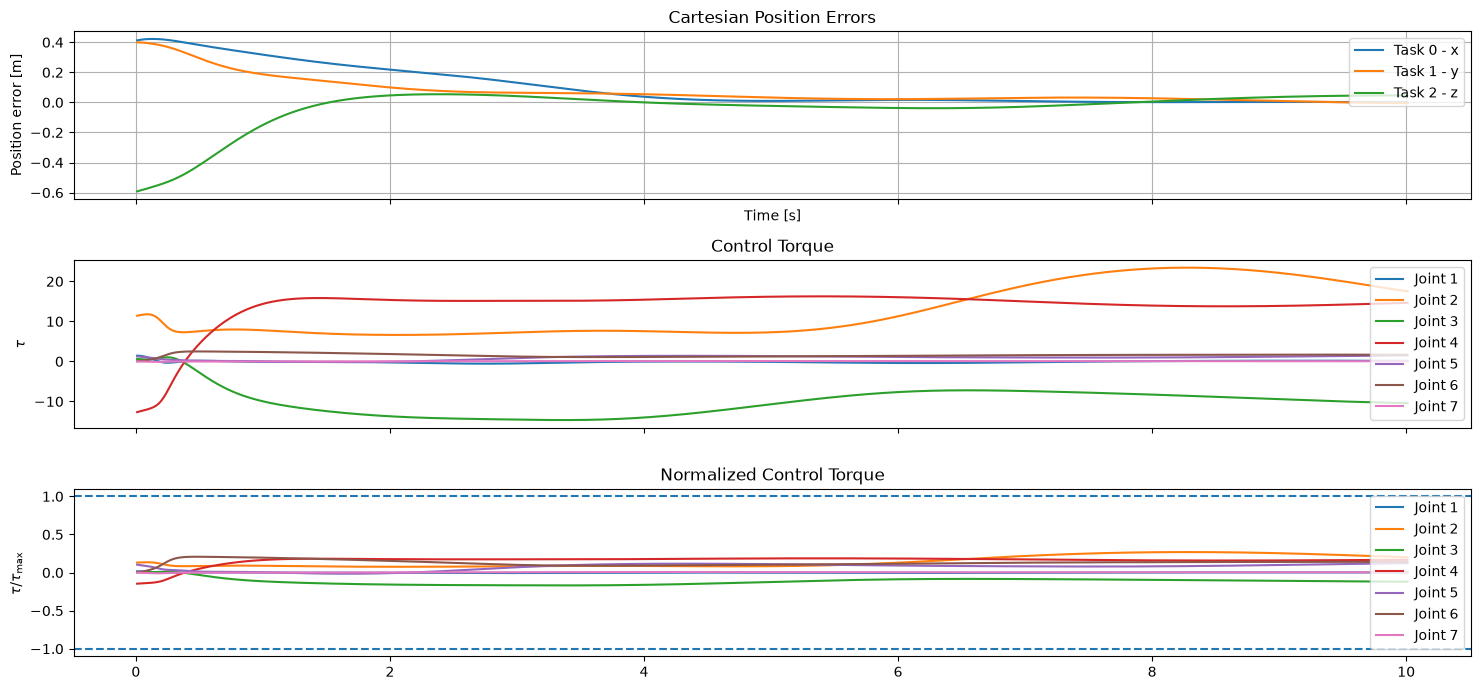

In [4]:
# QP based controller (as in the paper)

tau_cmd_hist, tasks, torque_limits, computation_times = run(tasks=tasks, controller=TorqueControllerQP())
mean_time = np.mean(np.array(computation_times))
print(
    f"average controller computation time:\t{mean_time * 1e3:.3f} ms"
)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)

average controller computation time:	0.083 ms


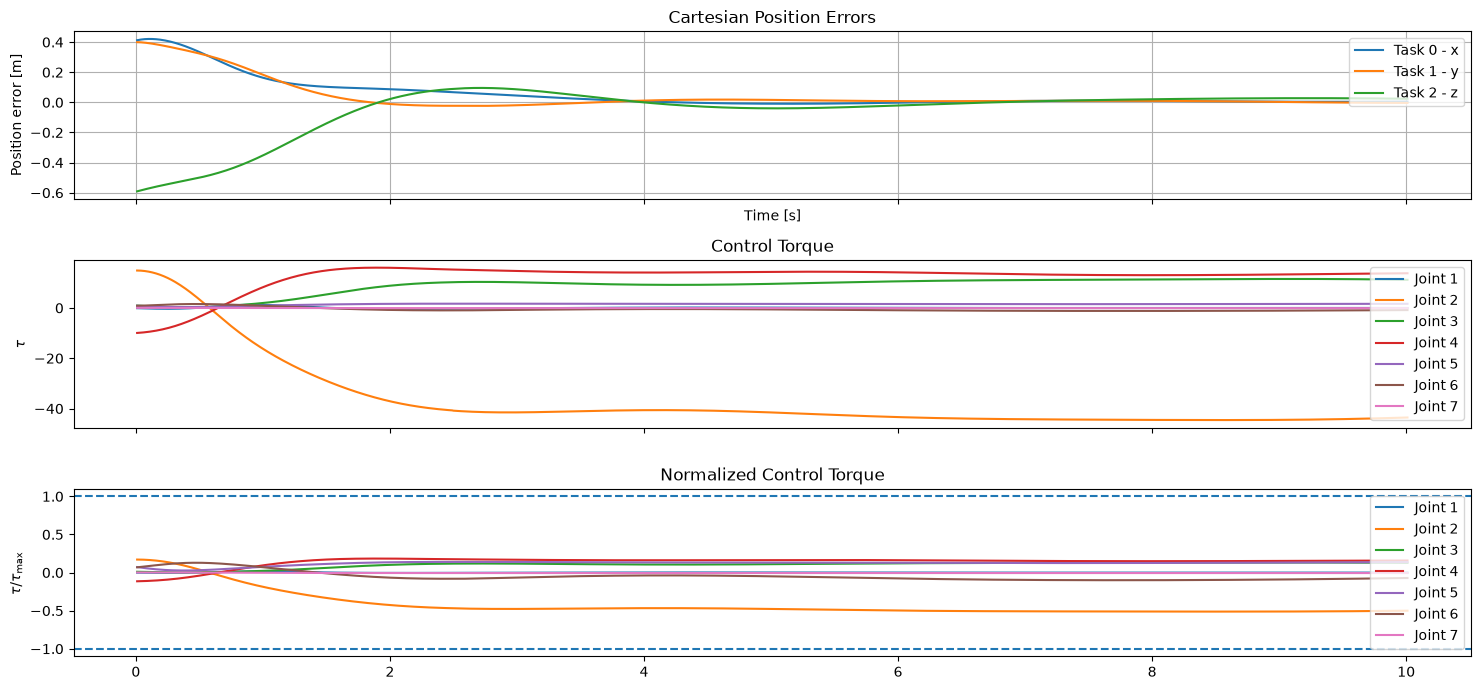

In [5]:
# traditional nullspace controller (as in the lecture)

tau_cmd_hist, tasks, torque_limits, computation_times = run(tasks=tasks, controller=TorqueControllerTraditional())
mean_time = np.mean(np.array(computation_times))
print(
    f"average controller computation time:\t{mean_time * 1e3:.3f} ms"
)
plot_cartesian_pos_errors(tasks=tasks, tau=tau_cmd_hist, torque_limits=torque_limits)